In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline 

In [5]:
# read all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [6]:
len(words)

32033

In [7]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [8]:
# build the dataset
block_size = 3
X, Y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [109]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [9]:
X.shape,  Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [10]:
C = torch.randn((27,2))

In [11]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [12]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [13]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1)

In [14]:
h.shape

torch.Size([228146, 100])

In [15]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [16]:
logits = h @ W2 + b2

In [17]:
logits.shape

torch.Size([228146, 27])

In [18]:
counts = logits.exp()

In [19]:
prob = counts / counts.sum(1, keepdims = True)

In [20]:
prob.shape

torch.Size([228146, 27])

In [21]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [22]:
# more respectable 

In [23]:
Xtr.shape, Ytr.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [246]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,26), generator = g)
W1 = torch.randn((78,200), generator = g)
b1 = torch.randn(200, generator = g)
W2 = torch.randn((200, 27), generator = g)
b2 = torch.randn(27, generator = g)
parameters = [C, W1, b1, W2, b2]

In [243]:
sum(p.nelement() for p in parameters)

12329

In [247]:
for p in parameters:
    p.requires_grad = True

In [226]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [260]:
# lri = []
# lossi = []

for i in range(10000):

    # minibatch construct 
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 78) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.001
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    # lossi.append(loss.item())
print(loss)

tensor(2.1918, grad_fn=<NllLossBackward0>)


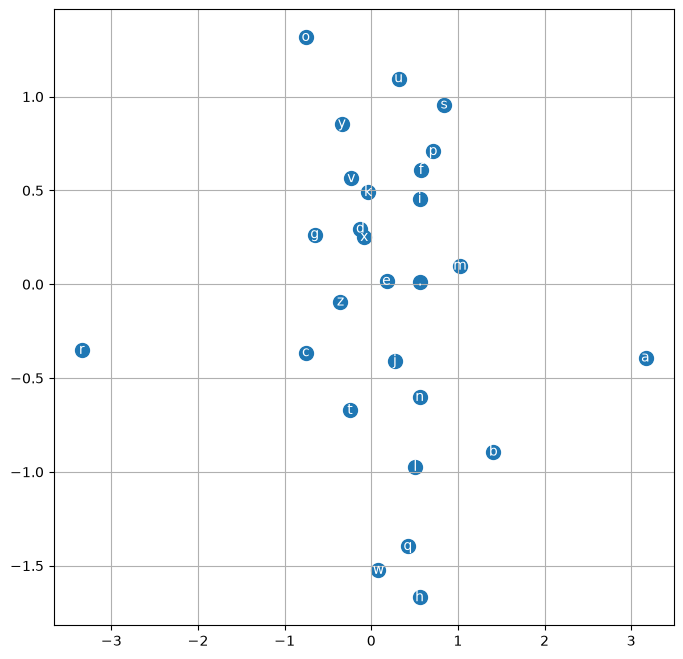

In [252]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s = 100)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i,1].item(), itos[i], ha = "center", va = "center", color = 'white')
plt.grid('minor')

In [261]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 78) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2443, grad_fn=<NllLossBackward0>)

In [262]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 78) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1721, grad_fn=<NllLossBackward0>)

In [265]:
g = torch.Generator().manual_seed(42)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples = 1, generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

anueden.
tis.
mari.
nedyn.
shawneglaylen.
kemarce.
man.
emiah.
nasilange.
kend.
josey.
gor.
lor.
mari.
yalah.
vahia.
achalivittar.
tieela.
ashtan.
selin.


In [40]:
ix = torch.randint(0, X.shape[0], (32,))
ix

tensor([ 95265,  55748, 103202, 161477,  64598,    469,  83164, 198325, 126488,
        156897,  67568, 203843, 122283, 131483,  79037,   7329, 148249, 199349,
         43787, 128280,   8157,  14461,  62886,   6187, 203769, 178644, 119008,
        211464, 146880,  83383,  54517, 126089])